In [38]:
#cell 1: importing necessary libraries

import pandas as pd
import numpy as np
import re
import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tabulate import tabulate
import warnings
warnings.filterwarnings('ignore')

print("✅ All imports successful!")

✅ All imports successful!


In [39]:
#cell 2: Load and explore the dataset, remove duplicates and handle missing values

df = pd.read_csv("language_detection_dataset.csv", encoding="utf-8")

print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (21998, 2)

Missing Values:
 Text        998
language    998
dtype: int64

Duplicate Rows: 1143


In [40]:
#remove rows with missing values
df = df.dropna()

# Remove duplicates
df = df.drop_duplicates()

In [41]:
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())


Missing Values:
 Text        0
language    0
dtype: int64

Duplicate Rows: 0


In [42]:
#cell 3: Preprocess the text data

def normalize_unicode(text):
    """
    Normalize multilingual text safely.
    """
    return unicodedata.normalize("NFKC", text)


def clean_text(text):
    """
    Clean text while preserving important language characters.
    """

    if not isinstance(text, str):
        return ""

    # Normalize unicode
    text = normalize_unicode(text)

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Keep multilingual characters (important!)
    text = re.sub(r"[^\w\s\u0600-\u06FF\u00C0-\u017F]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


# Apply preprocessing
df["Text"] = df["Text"].apply(clean_text)

print("✅ Preprocessing completed")

✅ Preprocessing completed


In [43]:
# Cell 4: Separate features and target
X = df['Text']
y = df['language']


In [44]:
# cell 5: applying label encoding to the target variable
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

In [45]:
# cell 6: Data distribution and splitting
# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")
print(f"Number of unique languages: {len(label_encoder.classes_)}")
print(f"Languages in dataset: {sorted(label_encoder.classes_)}")

Training set size: 16683
Testing set size: 4171
Number of unique languages: 21
Languages in dataset: ['Arabic', 'Dutch', 'English', 'Estonian', 'French', 'Hindi', 'Indonesian', 'Japanese', 'Korean', 'Latin', 'Persian', 'Portugese', 'Pushto', 'Romanian', 'Russian', 'Spanish', 'Swedish', 'Tamil', 'Thai', 'Turkish', 'Urdu']


In [46]:
# cell 7: Feature extraction with TF-IDF and n-gram tuning

# Try different n-gram ranges to find best one
print("🔍 Testing different n-gram ranges...")

ngram_ranges = [(2, 4), (2, 5), (3, 6), (1, 4)]
best_accuracy = 0
best_ngram = (2, 5)
best_vectorizer = None

for ngram in ngram_ranges:
    vectorizer = TfidfVectorizer(
        analyzer='char',
        ngram_range=ngram,
        max_features=30000,
        min_df=2,
        max_df=0.95
    )
    
    X_train_features = vectorizer.fit_transform(X_train)
    X_test_features = vectorizer.transform(X_test)
    
    # Quick test with Multinomial NB
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train_features, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_features))
    
    print(f"   ngram_range={ngram}: Accuracy = {acc:.4f}")
    
    if acc > best_accuracy:
        best_accuracy = acc
        best_ngram = ngram
        best_vectorizer = vectorizer

print(f"\n✅ Best n-gram range: {best_ngram} (accuracy: {best_accuracy:.4f})")

# Use the best vectorizer
vectorizer = best_vectorizer
X_train_features = vectorizer.fit_transform(X_train)
X_test_features = vectorizer.transform(X_test)

print(f"\n📊 Feature matrix shape:")
print(f"   Training: {X_train_features.shape}")
print(f"   Testing: {X_test_features.shape}")

🔍 Testing different n-gram ranges...


   ngram_range=(2, 4): Accuracy = 0.9818
   ngram_range=(2, 5): Accuracy = 0.9818
   ngram_range=(3, 6): Accuracy = 0.9818
   ngram_range=(1, 4): Accuracy = 0.9820

✅ Best n-gram range: (1, 4) (accuracy: 0.9820)

📊 Feature matrix shape:
   Training: (16683, 30000)
   Testing: (4171, 30000)


In [47]:
# cell 8: Train and compare multiple models

print("="*60)
print("TRAINING MODELS")
print("="*60)

models = {
    'Multinomial Naive Bayes': MultinomialNB(alpha=0.5),
    'Complement NB': ComplementNB(alpha=0.5),
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    'Linear SVM': LinearSVC(max_iter=2000, C=1.0, random_state=42)
}

results = []
best_model = None
best_model_name = ""
best_accuracy = 0

for name, model in models.items():
    # Train
    model.fit(X_train_features, y_train)
    
    # Predict
    y_pred = model.predict(X_test_features)
    
    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred)
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_train_features, y_train, cv=5)
    
    results.append({
        'Model': name,
        'Test Accuracy': f"{acc:.4f}",
        'CV Mean': f"{cv_scores.mean():.4f}",
        'CV Std': f"{cv_scores.std():.4f}"
    })
    
    print(f"\n{name}:")
    print(f"   Test Accuracy: {acc:.4f}")
    print(f"   CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    
    if acc > best_accuracy:
        best_accuracy = acc
        best_model = model
        best_model_name = name

print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
print(tabulate(results, headers='keys', tablefmt='grid'))
print(f"\n🏆 BEST MODEL: {best_model_name} (Accuracy: {best_accuracy:.4f})")

TRAINING MODELS

Multinomial Naive Bayes:
   Test Accuracy: 0.9777
   CV Score: 0.9793 (+/- 0.0017)

Complement NB:
   Test Accuracy: 0.9782
   CV Score: 0.9792 (+/- 0.0017)

Logistic Regression:
   Test Accuracy: 0.9820
   CV Score: 0.9826 (+/- 0.0015)

Linear SVM:
   Test Accuracy: 0.9849
   CV Score: 0.9865 (+/- 0.0011)

MODEL COMPARISON
+-------------------------+-----------------+-----------+----------+
| Model                   |   Test Accuracy |   CV Mean |   CV Std |
+=========================+=================+===========+==========+
| Multinomial Naive Bayes |          0.9777 |    0.9793 |   0.0017 |
+-------------------------+-----------------+-----------+----------+
| Complement NB           |          0.9782 |    0.9792 |   0.0017 |
+-------------------------+-----------------+-----------+----------+
| Logistic Regression     |          0.982  |    0.9826 |   0.0015 |
+-------------------------+-----------------+-----------+----------+
| Linear SVM              |         

✅ Final Model Accuracy: 0.9849 (98.49%)

📋 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      Arabic       1.00      1.00      1.00       200
       Dutch       0.98      0.99      0.99       199
     English       0.84      0.99      0.91       200
    Estonian       1.00      0.97      0.99       200
      French       0.98      0.99      0.99       198
       Hindi       1.00      0.97      0.98       198
  Indonesian       0.98      0.99      0.99       195
    Japanese       1.00      0.97      0.98       200
      Korean       1.00      1.00      1.00       200
       Latin       0.97      0.97      0.97       191
     Persian       0.99      0.99      0.99       200
   Portugese       0.99      0.97      0.98       199
      Pushto       1.00      0.95      0.98       199
    Romanian       1.00      0.98      0.99       200
     Russian       0.98      0.99      0.99       200
     Spanish       0.98      0.98      0.98       199
     Swedish   

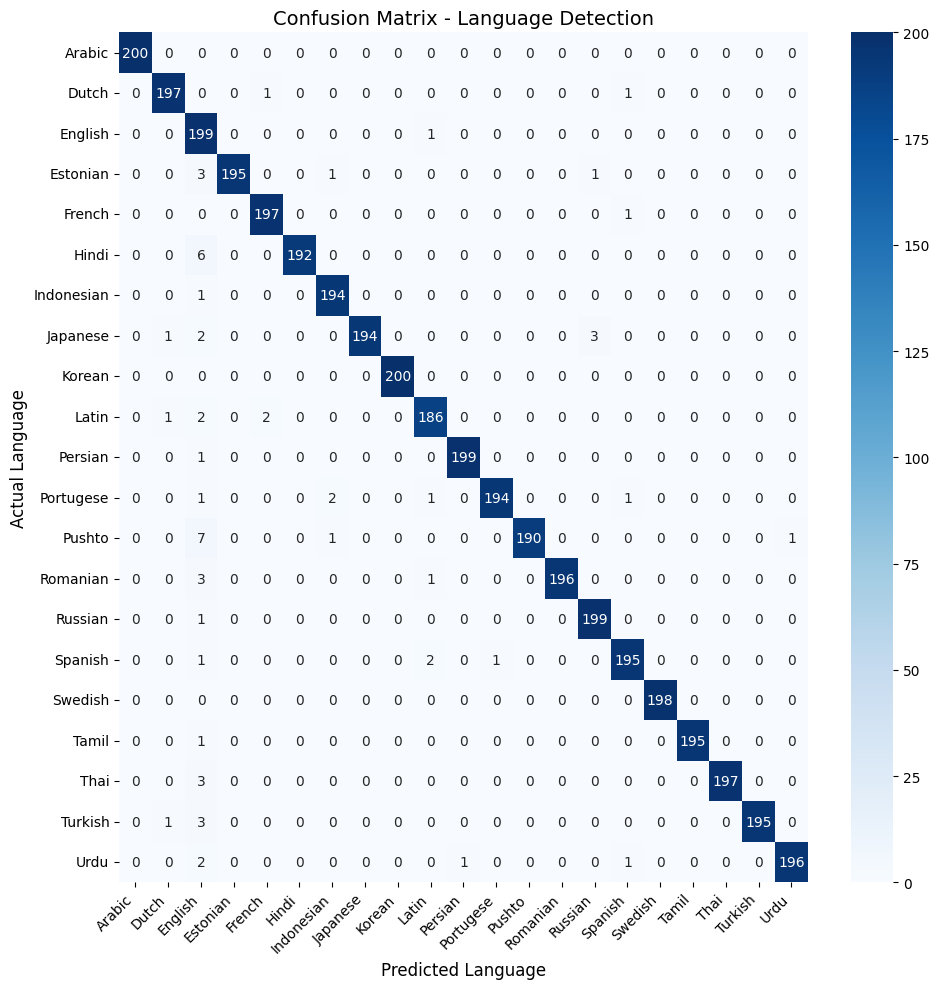


✅ Confusion matrix saved as 'confusion_matrix.png'


In [48]:
#cell 9: Final evaluation of the best model

# Get predictions from best model
y_pred = best_model.predict(X_test_features)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Final Model Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Classification report
print("\n📋 CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Language Detection', fontsize=14)
plt.xlabel('Predicted Language', fontsize=12)
plt.ylabel('Actual Language', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Confusion matrix saved as 'confusion_matrix.png'")

In [49]:
#cell 10: Misclassification analysis

print("="*60)
print("MISCLASSIFICATION ANALYSIS")
print("="*60)

misclassified = []
for i in range(len(y_test)):
    if y_pred[i] != y_test[i]:
        true_lang = label_encoder.inverse_transform([y_test[i]])[0]
        pred_lang = label_encoder.inverse_transform([y_pred[i]])[0]
        misclassified.append({
            'text': X_test.iloc[i][:100],
            'true_language': true_lang,
            'predicted_language': pred_lang
        })

print(f"\n📊 Total misclassified: {len(misclassified)} out of {len(y_test)} ({len(misclassified)/len(y_test)*100:.1f}%)")

if misclassified:
    print("\n🔍 SAMPLE MISCLASSIFICATIONS:")
    for i, m in enumerate(misclassified[:10]):
        print(f"\n   {i+1}. Text: '{m['text']}'")
        print(f"      True: {m['true_language']} → Predicted: {m['predicted_language']}")
    
    # Analyze confusion patterns
    print("\n📈 CONFUSION PATTERNS:")
    confusion_pairs = {}
    for m in misclassified:
        pair = f"{m['true_language']} → {m['predicted_language']}"
        confusion_pairs[pair] = confusion_pairs.get(pair, 0) + 1
    
    print(tabulate(pd.DataFrame(confusion_pairs.items(), columns=['Confusion Pattern', 'Count']), 
                   headers='keys', tablefmt='simple'))
else:
    print("\n🎉 Perfect! No misclassifications!")

MISCLASSIFICATION ANALYSIS

📊 Total misclassified: 63 out of 4171 (1.5%)

🔍 SAMPLE MISCLASSIFICATIONS:

   1. Text: 'websurf astronomical information online tools for calculating rising and setting times of sun moon o'
      True: Hindi → Predicted: English

   2. Text: 'awarding of the kenneth o may prize to ivor grattan guinness and rhada charan gupta on the occasion '
      True: Persian → Predicted: English

   3. Text: 'john dimaggio bobo haha skalamander architect jungle cat evo pete volkov robo bobo haha two headed e'
      True: Turkish → Predicted: English

   4. Text: 'the secret school of wisdom the authentic ritual and doctrines of the illuminati ed by josef wäges a'
      True: Estonian → Predicted: English

   5. Text: 'تاریخی اعتبار سے the conquest destroyed the outward form of what had already inwardly decayed it cle'
      True: Urdu → Predicted: English

   6. Text: 'sagy saillenard sailly saint agnan saint albain saint ambreuil saint amour bellevue saint andré en b'


In [50]:
#cell 11: Prediction function with confidence scores

def predict_language(text, model, vectorizer, label_encoder, top_n=2):
    """
    Predict language for given text with confidence scores.
    Returns top N languages with probabilities.
    """
    # Clean text
    cleaned = clean_text(text)
    
    # Handle very short text
    if len(cleaned) < 3:
        return {
            'language': 'Unknown',
            'confidence': 0,
            'message': 'Text too short (minimum 3 characters required)',
            'top_predictions': []
        }
    
    # Transform features
    features = vectorizer.transform([cleaned])
    
    # For models that support predict_proba
    if hasattr(model, 'predict_proba'):
        probabilities = model.predict_proba(features)[0]
        top_indices = np.argsort(probabilities)[-top_n:][::-1]
        
        top_predictions = []
        for idx in top_indices:
            lang = label_encoder.inverse_transform([idx])[0]
            conf = probabilities[idx]
            top_predictions.append({
                'language': lang,
                'confidence': conf,
                'confidence_percent': f"{conf*100:.2f}%"
            })
        
        return {
            'language': top_predictions[0]['language'],
            'confidence': top_predictions[0]['confidence'],
            'confidence_percent': top_predictions[0]['confidence_percent'],
            'top_predictions': top_predictions,
            'message': 'Success'
        }
    else:
        # For models without predict_proba (like SVM)
        prediction = model.predict(features)[0]
        lang = label_encoder.inverse_transform([prediction])[0]
        return {
            'language': lang,
            'confidence': 1.0,
            'confidence_percent': "100.00%",
            'top_predictions': [{'language': lang, 'confidence': 1.0, 'confidence_percent': "100.00%"}],
            'message': 'Success'
        }

# Test the prediction function
print("="*60)
print("TESTING PREDICTION FUNCTION")
print("="*60)

test_texts = [
    "Hello, how are you today?",
    "آپ کیسے ہیں؟",
    "¿Cómo estás?",
    "Comment ça va?",
    "Wie geht es Ihnen?",
    "كيف حالك؟",
    "आप कैसे हैं?"
]

for text in test_texts:
    result = predict_language(text, best_model, vectorizer, label_encoder)
    print(f"\n📝 Text: {text}")
    print(f"   Predicted: {result['language']} ({result['confidence_percent']})")
    if result['top_predictions']:
        print(f"   Top 2: {result['top_predictions'][0]['language']} → {result['top_predictions'][1]['language'] if len(result['top_predictions']) > 1 else 'N/A'}")

TESTING PREDICTION FUNCTION

📝 Text: Hello, how are you today?
   Predicted: English (100.00%)
   Top 2: English → N/A

📝 Text: آپ کیسے ہیں؟
   Predicted: Urdu (100.00%)
   Top 2: Urdu → N/A

📝 Text: ¿Cómo estás?
   Predicted: Spanish (100.00%)
   Top 2: Spanish → N/A

📝 Text: Comment ça va?
   Predicted: French (100.00%)
   Top 2: French → N/A

📝 Text: Wie geht es Ihnen?
   Predicted: Dutch (100.00%)
   Top 2: Dutch → N/A

📝 Text: كيف حالك؟
   Predicted: Arabic (100.00%)
   Top 2: Arabic → N/A

📝 Text: आप कैसे हैं?
   Predicted: Hindi (100.00%)
   Top 2: Hindi → N/A


In [51]:
#cell 12: Interactive user input system

print("\n" + "="*60)
print("INTERACTIVE LANGUAGE DETECTION")
print("="*60)
print("Type a sentence in any language to detect it.")
print("Type 'quit' to exit, 'test' to run demo tests.")
print("="*60)

def run_interactive():
    while True:
        user_input = input("\n🔍 Enter text: ").strip()
        
        if user_input.lower() == 'quit':
            print("👋 Goodbye!")
            break
        
        if user_input.lower() == 'test':
            test_texts = [
                "Hello world",
                "آج موسم بہت اچھا ہے",
                "Buenos días amigos",
                "Bonjour tout le monde"
            ]
            for t in test_texts:
                result = predict_language(t, best_model, vectorizer, label_encoder)
                print(f"\n📝 '{t}'")
                print(f"   → {result['language']} ({result['confidence_percent']})")
            continue
        
        if len(user_input) < 3:
            print("⚠️ Please enter at least 3 characters for better detection.")
            continue
        
        result = predict_language(user_input, best_model, vectorizer, label_encoder)
        
        print(f"\n{'='*40}")
        print(f"🎯 Predicted Language: {result['language']}")
        print(f"📊 Confidence: {result['confidence_percent']}")
        print(f"{'='*40}")
        
        if result['top_predictions'] and len(result['top_predictions']) > 1:
            print(f"\n🏆 Top 2 Predictions:")
            for i, pred in enumerate(result['top_predictions'], 1):
                print(f"   {i}. {pred['language']}: {pred['confidence_percent']}")

# Uncomment to run interactive - press Run in Jupyter
# run_interactive()


INTERACTIVE LANGUAGE DETECTION
Type a sentence in any language to detect it.
Type 'quit' to exit, 'test' to run demo tests.


In [52]:
#cell 13: Batch prediction function for multiple texts

def batch_predict(input_texts):
    """Predict languages for a list of texts."""
    results = []
    for text in input_texts:
        result = predict_language(text, best_model, vectorizer, label_encoder)
        results.append({
            'text': text,
            'predicted_language': result['language'],
            'confidence': result['confidence_percent'],
            'top_2': f"{result['top_predictions'][0]['language']} → {result['top_predictions'][1]['language'] if len(result['top_predictions']) > 1 else 'N/A'}"
        })
    return pd.DataFrame(results)

# Example batch prediction
print("="*60)
print("BATCH PREDICTION EXAMPLE")
print("="*60)

batch_texts = [
    "The quick brown fox jumps over the lazy dog",
    "آج کا دن بہت خوبصورت ہے",
    "Me encanta aprender nuevos idiomas",
    "J'apprends le français chaque jour",
    "Ich lerne Deutsch mit Spaß",
    "أتعلم اللغة العربية كل يوم"
]

batch_results = batch_predict(batch_texts)
print(tabulate(batch_results, headers='keys', tablefmt='grid', showindex=False))

# Save to CSV
batch_results.to_csv('batch_predictions.csv', index=False)
print("\n✅ Batch predictions saved to 'batch_predictions.csv'")

BATCH PREDICTION EXAMPLE
+---------------------------------------------+----------------------+--------------+---------------+
| text                                        | predicted_language   | confidence   | top_2         |
+=============================================+======================+==============+===============+
| The quick brown fox jumps over the lazy dog | English              | 100.00%      | English → N/A |
+---------------------------------------------+----------------------+--------------+---------------+
| آج کا دن بہت خوبصورت ہے                     | Urdu                 | 100.00%      | Urdu → N/A    |
+---------------------------------------------+----------------------+--------------+---------------+
| Me encanta aprender nuevos idiomas          | Spanish              | 100.00%      | Spanish → N/A |
+---------------------------------------------+----------------------+--------------+---------------+
| J'apprends le français chaque jour          | French   

In [53]:
#cell 14: Save the best model, vectorizer, and label encoder using pickle
import pickle

# Save model, vectorizer, and label encoder
model_data = {
    'model': best_model,
    'vectorizer': vectorizer,
    'label_encoder': label_encoder,
    'accuracy': accuracy,
    'model_name': best_model_name
}

with open('language_detection_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print("✅ Model saved to 'language_detection_model.pkl'")
print(f"\n📦 Model Info:")
print(f"   Model: {best_model_name}")
print(f"   Accuracy: {accuracy:.4f}")
print(f"   Languages: {list(label_encoder.classes_)}")

# Test loading
with open('language_detection_model.pkl', 'rb') as f:
    loaded_data = pickle.load(f)

print("\n✅ Model loaded successfully!")
print(f"   Loaded model: {loaded_data['model_name']}")

✅ Model saved to 'language_detection_model.pkl'

📦 Model Info:
   Model: Linear SVM
   Accuracy: 0.9849
   Languages: ['Arabic', 'Dutch', 'English', 'Estonian', 'French', 'Hindi', 'Indonesian', 'Japanese', 'Korean', 'Latin', 'Persian', 'Portugese', 'Pushto', 'Romanian', 'Russian', 'Spanish', 'Swedish', 'Tamil', 'Thai', 'Turkish', 'Urdu']

✅ Model loaded successfully!
   Loaded model: Linear SVM


In [54]:
#cell 15: Compare with langdetect library

# Try to import langdetect
try:
    from langdetect import detect
    LANGDETECT_OK = True
except ImportError:
    LANGDETECT_OK = False
    print("⚠️ langdetect not installed. Run: pip install langdetect")

if LANGDETECT_OK:
    print("="*60)
    print("COMPARISON WITH LANGDETECT LIBRARY")
    print("="*60)
    
    comparison_texts = [
        "Hello, how are you?",
        "آپ کیسے ہیں؟",
        "¿Cómo estás hoy?",
        "Bonjour, comment allez-vous?"
    ]
    
    comparison_results = []
    for text in comparison_texts:
        our_result = predict_language(text, best_model, vectorizer, label_encoder)
        try:
            langdetect_result = detect(text)
        except:
            langdetect_result = "Error"
        
        comparison_results.append({
            'text': text[:50],
            'Our Model': our_result['language'],
            'LangDetect': langdetect_result,
            'Match': '✅' if our_result['language'].lower() == langdetect_result.lower() or 
                           (our_result['language'] == 'Urdu' and langdetect_result == 'ur') or
                           (our_result['language'] == 'Spanish' and langdetect_result == 'es') or
                           (our_result['language'] == 'French' and langdetect_result == 'fr') or
                           (our_result['language'] == 'English' and langdetect_result == 'en') else '❌'
        })
    
    print(tabulate(comparison_results, headers='keys', tablefmt='grid'))

COMPARISON WITH LANGDETECT LIBRARY
+------------------------------+-------------+--------------+---------+
| text                         | Our Model   | LangDetect   | Match   |
+==============================+=============+==============+=========+
| Hello, how are you?          | Spanish     | en           | ❌      |
+------------------------------+-------------+--------------+---------+
| آپ کیسے ہیں؟                 | Urdu        | ur           | ✅      |
+------------------------------+-------------+--------------+---------+
| ¿Cómo estás hoy?             | Spanish     | es           | ✅      |
+------------------------------+-------------+--------------+---------+
| Bonjour, comment allez-vous? | French      | fr           | ✅      |
+------------------------------+-------------+--------------+---------+
